# 03 — Label Construction
**Part A | Milestone 3**

Goal: show, step by step, how the drift label is built — and demonstrate
the sanity check that confirms the labels make physical sense.

This notebook uses the same functions as `scripts/make_windows.py`, just
run interactively with plots in between so the process is visible.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vio_drift.data.loader import load_sequence
from vio_drift.data.align import align_imu_to_groundtruth
from vio_drift.data.windowing import make_windows
from vio_drift.labels.imu_integration import calibrate_conventions
from vio_drift.labels.drift_label import compute_drift_label

config = yaml.safe_load((Path.cwd().parent / "configs" / "config.yaml").read_text())
raw_dir = Path.cwd().parent / config["data"]["raw_dir"]
seq_name = config["data"]["sequences"][0]
seq_name

'MH_01_easy'

## Step 1–2: load and align

In [2]:
imu_df, gt_df = load_sequence(raw_dir, seq_name)
aligned = align_imu_to_groundtruth(imu_df, gt_df)
print(f"{len(aligned)} aligned rows")
aligned.head()

[align] dropped 431/36820 IMU rows (1.17%) with no ground-truth match within 20.0 ms
36389 aligned rows


,t_ns,gx,gy,gz,ax,ay,az,gt_t_ns,gt_px,gt_py,...,gt_vx,gt_vy,gt_vz,gt_bgx,gt_bgy,gt_bgz,gt_bax,gt_bay,gt_baz,gt_gap_ns
0,1403636580823555584,-0.186401,0.300197,-0.034907,10.231605,-0.294199,-4.274065,1403636580838555648,4.688319,-1.786938,...,-0.027876,0.033207,0.800006,-0.003172,0.021267,0.078502,-0.025266,0.136696,0.075593,-15000064
1,1403636580828555520,-0.194779,0.304385,-0.027925,10.247949,-0.253338,-4.184171,1403636580838555648,4.688319,-1.786938,...,-0.027876,0.033207,0.800006,-0.003172,0.021267,0.078502,-0.025266,0.136696,0.075593,-10000128
2,1403636580833555456,-0.198968,0.311367,-0.032812,10.182572,-0.220650,-4.143310,1403636580838555648,4.688319,-1.786938,...,-0.027876,0.033207,0.800006,-0.003172,0.021267,0.078502,-0.025266,0.136696,0.075593,-5000192
3,1403636580838555392,-0.206647,0.325329,-0.040492,10.035472,-0.179789,-4.135137,1403636580838555648,4.688319,-1.786938,...,-0.027876,0.033207,0.800006,-0.003172,0.021267,0.078502,-0.025266,0.136696,0.075593,-256
4,1403636580843555584,-0.215025,0.333009,-0.046775,9.749445,-0.024517,-4.077932,1403636580843555328,4.688177,-1.786770,...,-0.029272,0.033992,0.804771,-0.003172,0.021267,0.078502,-0.025266,0.136696,0.075593,256


## Step 3: calibrate gravity sign & rotation convention

This tries all 4 combinations on a short real slice of data and picks the
one with lowest error — the printed table shows why the winner was chosen,
not just the answer.

In [3]:
best = calibrate_conventions(aligned, gravity_magnitude=config["integration"]["gravity_magnitude"])
best

[calibrate_conventions] tried 4 combinations over a 0.25s probe:
    sign=-1  conv=body_to_world  probe_error=0.0169 m
    sign=+1  conv=world_to_body  probe_error=0.2702 m
    sign=-1  conv=world_to_body  probe_error=0.5337 m
    sign=+1  conv=body_to_world  probe_error=0.6290 m
[calibrate_conventions] chosen: sign=-1, conv=body_to_world (probe_error=0.0169 m)


{'gravity_sign': -1,
 'rotation_convention': 'body_to_world',
 'probe_error_m': 0.01686701371224489}

## Step 4: cut into windows and compute drift labels

One window = ~1 second of IMU data. For each window we integrate the raw
IMU readings starting from the true state, then compare the predicted end
position to the true end position.

In [5]:
expected_rows = int(config["windowing"]["window_seconds"] * config["windowing"]["imu_rate_hz"])

windows = make_windows(
    aligned, seq_name,
    window_seconds=config["windowing"]["window_seconds"],
    stride_seconds=config["windowing"]["stride_seconds"],
    expected_rows=expected_rows,
)

labels = [
    compute_drift_label(w, gravity_magnitude=config["integration"]["gravity_magnitude"],
                         gravity_sign=best["gravity_sign"],
                         rotation_convention=best["rotation_convention"])
    for w in windows
]
labels = [l for l in labels if l is not None]

labels_df = pd.DataFrame([vars(l) for l in labels])
labels_df.head()

[windowing] MH_01_easy: produced 724 windows


,seq_name,window_id,t_start_ns,t_end_ns,err_mag_m,err_dx,err_dy,err_dz
0,MH_01_easy,0,1403636580823555584,1403636581823555584,0.139936,0.073071,0.119106,0.007504
1,MH_01_easy,1,1403636581073555584,1403636582073555584,0.152153,0.081449,0.126858,-0.020584
2,MH_01_easy,2,1403636581323555584,1403636582323555584,0.171830,0.079857,0.150745,-0.020597
3,MH_01_easy,3,1403636581573555584,1403636582573555584,0.186876,0.081040,0.167720,-0.015009
4,MH_01_easy,4,1403636581823555584,1403636582823555584,0.181881,0.081469,0.162373,-0.008859


## Distribution of the drift label

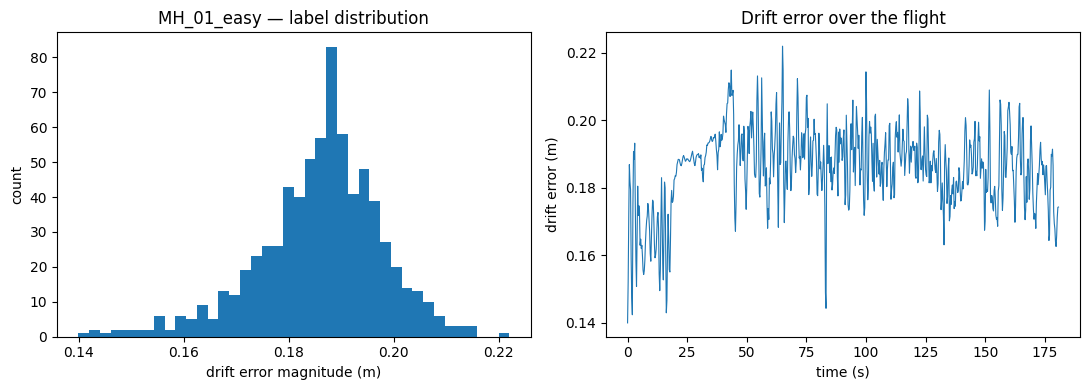

mean=0.1859 m, median=0.1875 m, max=0.2220 m


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(labels_df["err_mag_m"], bins=40)
axes[0].set_xlabel("drift error magnitude (m)")
axes[0].set_ylabel("count")
axes[0].set_title(f"{seq_name} — label distribution")

t_start_s = (labels_df["t_start_ns"] - labels_df["t_start_ns"].iloc[0]) / 1e9
axes[1].plot(t_start_s, labels_df["err_mag_m"], linewidth=0.8)
axes[1].set_xlabel("time (s)")
axes[1].set_ylabel("drift error (m)")
axes[1].set_title("Drift error over the flight")

plt.tight_layout()
plt.savefig(Path.cwd().parent / "figures" / "eda" / "label_distribution.png", dpi=150)
plt.show()

print(f"mean={labels_df['err_mag_m'].mean():.4f} m, "
      f"median={labels_df['err_mag_m'].median():.4f} m, "
      f"max={labels_df['err_mag_m'].max():.4f} m")

## The key sanity check: does error grow with window length?

This is the same check `tests/test_label_sanity.py` runs automatically —
here we can see it as a plot, not just pass/fail.

[windowing] MH_01_easy: produced 727 windows
window=0.25s -> mean error=0.0062 m over 80 windows
[windowing] MH_01_easy: produced 363 windows
window=0.5s -> mean error=0.0306 m over 80 windows
[windowing] MH_01_easy: produced 181 windows
window=1.0s -> mean error=0.1847 m over 80 windows
[windowing] MH_01_easy: produced 121 windows
window=1.5s -> mean error=0.5491 m over 80 windows
[windowing] MH_01_easy: produced 90 windows
window=2.0s -> mean error=1.2149 m over 80 windows


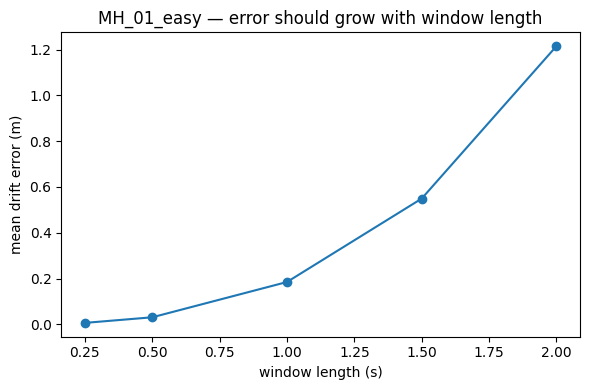

In [7]:
window_lengths = [0.25, 0.5, 1.0, 1.5, 2.0]
mean_errors = []

for wl in window_lengths:
    w = make_windows(aligned, seq_name, window_seconds=wl, stride_seconds=wl, expected_rows=None)
    errs = []
    for win in w[:80]:
        lab = compute_drift_label(win, gravity_magnitude=config["integration"]["gravity_magnitude"],
                                   gravity_sign=best["gravity_sign"],
                                   rotation_convention=best["rotation_convention"])
        if lab is not None:
            errs.append(lab.err_mag_m)
    mean_errors.append(np.mean(errs))
    print(f"window={wl}s -> mean error={np.mean(errs):.4f} m over {len(errs)} windows")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(window_lengths, mean_errors, marker="o")
ax.set_xlabel("window length (s)")
ax.set_ylabel("mean drift error (m)")
ax.set_title(f"{seq_name} — error should grow with window length")
plt.tight_layout()
plt.savefig(Path.cwd().parent / "figures" / "eda" / "error_vs_window_length.png", dpi=150)
plt.show()

**Expected shape:** an upward trend — longer windows accumulate more
drift. If this plot is flat or goes down, do not trust the labels yet;
re-run `scripts/verify_data.py` and check `docs/label_construction.md`
for what to look at.

## What we learned (fill this in after running)

- Mean drift error for 1s windows on this sequence: ___
- Does error clearly grow with window length? ___
- Anything that looks like an outlier or a labeling bug: ___
